In [ ]:
import torch
from diffusion.flows.prob_paths import GaussianCondProbPath
from diffusion.backbones.res_unet import ResUnet
from diffusion.matching.flow_generator import FlowGenerator, ScoreGenerator
from whar_datasets.support.getter import WHARDatasetID, get_dataset_cfg
from diffusion.sampleables.whar_sampleable import WHARSampleable, TrainValTest
from diffusion.architectures.classifiers.wisdm_classifier import WISDMClassifier
from diffusion.evaluation.evaluate import (
    visualize_tsne_per_class,
    compute_samples,
    plot_metrics_per_class,
    visualize_samples_per_class,
    compute_features,
    evaluate_features,
)

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [11]:
cfg = get_dataset_cfg(WHARDatasetID.UCI_HAR)
scv_group_index = 0

2025-12-21 11:39:13,641 - whar-datasets - INFO - Running DownloadingStep
2025-12-21 11:39:13,651 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-12-21 11:39:13,653 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:13,654 - whar-datasets - INFO - Running ParsingStep
2025-12-21 11:39:13,654 - whar-datasets - INFO - Checking hash for ParsingStep
2025-12-21 11:39:13,656 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:13,657 - whar-datasets - INFO - Running WindowingStep
2025-12-21 11:39:13,657 - whar-datasets - INFO - Checking hash for WindowingStep
2025-12-21 11:39:13,659 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:13,659 - whar-datasets - INFO - Loading windowing
2025-12-21 11:39:13,690 - whar-datasets - INFO - activity_ids from 0 to 5
2025-12-21 11:39:13,691 - whar-datasets - INFO - subject_ids from 0 to 29
2025-12-21 11:39:13,694 - whar-datasets - INFO - train: 8002 | test: 1497
2025-12-21 11:39:13,695 - whar-datasets - INFO - Ru

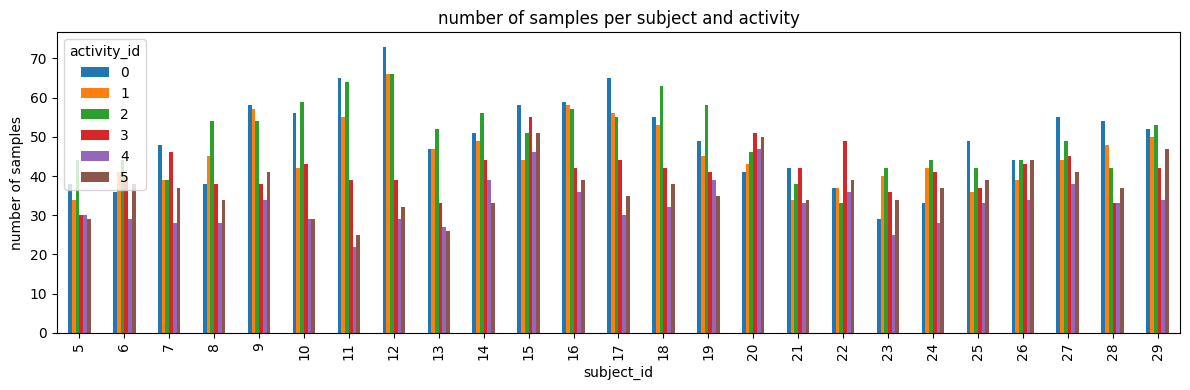

2025-12-21 11:39:16,542 - whar-datasets - INFO - Running DownloadingStep
2025-12-21 11:39:16,543 - whar-datasets - INFO - Checking hash for DownloadingStep
2025-12-21 11:39:16,543 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:16,544 - whar-datasets - INFO - Running ParsingStep
2025-12-21 11:39:16,544 - whar-datasets - INFO - Checking hash for ParsingStep
2025-12-21 11:39:16,545 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:16,545 - whar-datasets - INFO - Running WindowingStep
2025-12-21 11:39:16,545 - whar-datasets - INFO - Checking hash for WindowingStep
2025-12-21 11:39:16,546 - whar-datasets - INFO - Hash is up to date
2025-12-21 11:39:16,546 - whar-datasets - INFO - Loading windowing
2025-12-21 11:39:16,581 - whar-datasets - INFO - activity_ids from 0 to 5
2025-12-21 11:39:16,581 - whar-datasets - INFO - subject_ids from 0 to 29
2025-12-21 11:39:16,583 - whar-datasets - INFO - train: 8002 | test: 1497
2025-12-21 11:39:16,584 - whar-datasets - INFO - Ru

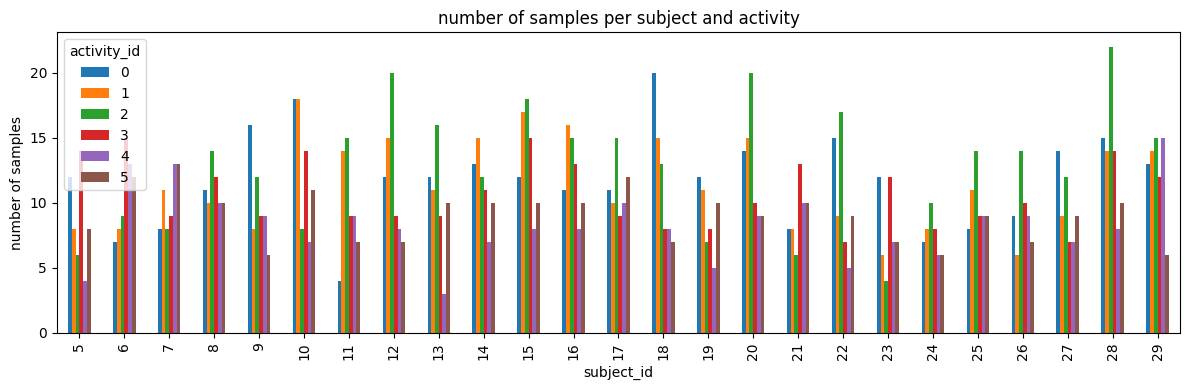

(128, 9)
(18, 33, 43)
6


In [12]:
sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.TRAIN,
)

val_sampeable = WHARSampleable(
    cfg=cfg,
    scv_group_index=scv_group_index,
    fold=TrainValTest.VAL,
)

print(sampeable.signal_shape)
print(sampeable.shape)
print(sampeable.num_classes)

In [14]:
path = GaussianCondProbPath(
    p_data=sampeable,
    p_simple_shape=sampeable.shape,
    alpha=LinearAlpha(),
    beta=LinearBeta(),
).to(device)

backbone = ResUnet(
    in_channels=sampeable.shape[0],
    channels=[16, 32, 64, 128],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)
backbone.load_state_dict(torch.load("./models/backbone_flow_ucihar.pt"))

classifier = WISDMClassifier(
    in_c=sampeable.shape[0], num_classes=sampeable.num_classes, size=5120
).to(device)
classifier.load_state_dict(torch.load("./models/classifier_ucihar.pt"))

<All keys matched successfully>

In [15]:
num_timesteps = 10
samples_per_class = 100
guidance_scale = 2.0

flow_generator = FlowGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_flow, real_list_flow = compute_samples(
    generator=flow_generator,
    p_data=val_sampeable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

x1_list_flow_t, real_list_flow_t = compute_samples(
    generator=flow_generator,
    p_data=val_sampeable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

# visualize_samples_per_class(x1_list_flow, real_list_flow)

100%|██████████| 9/9 [00:02<00:00,  3.18it/s]


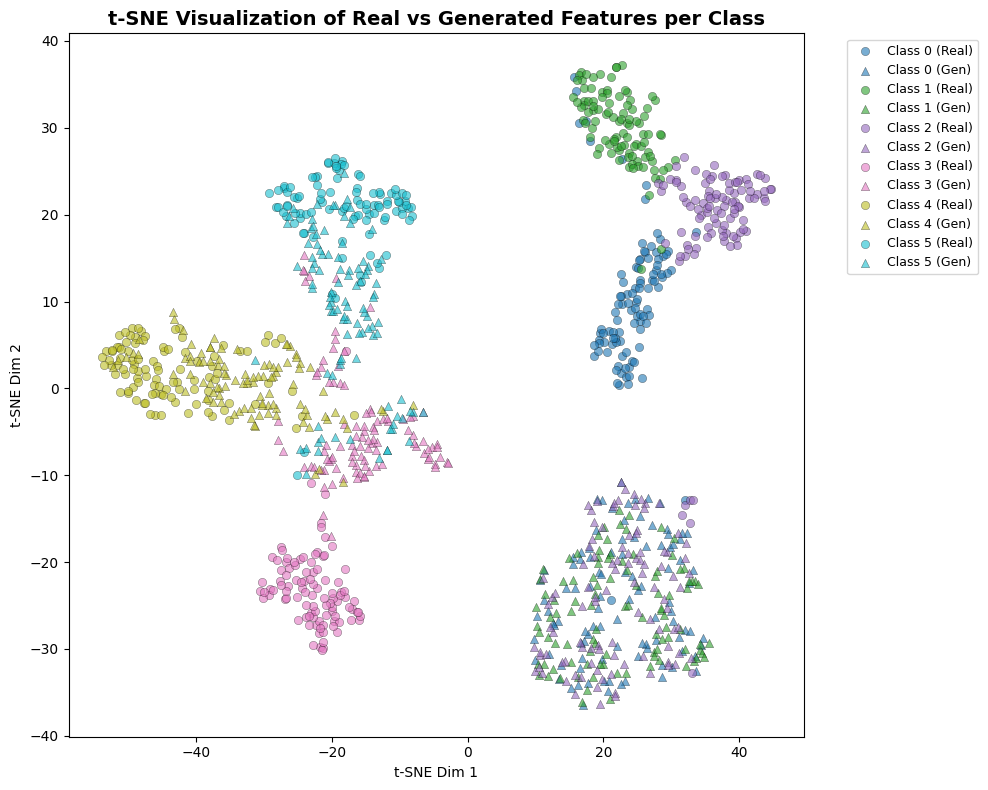

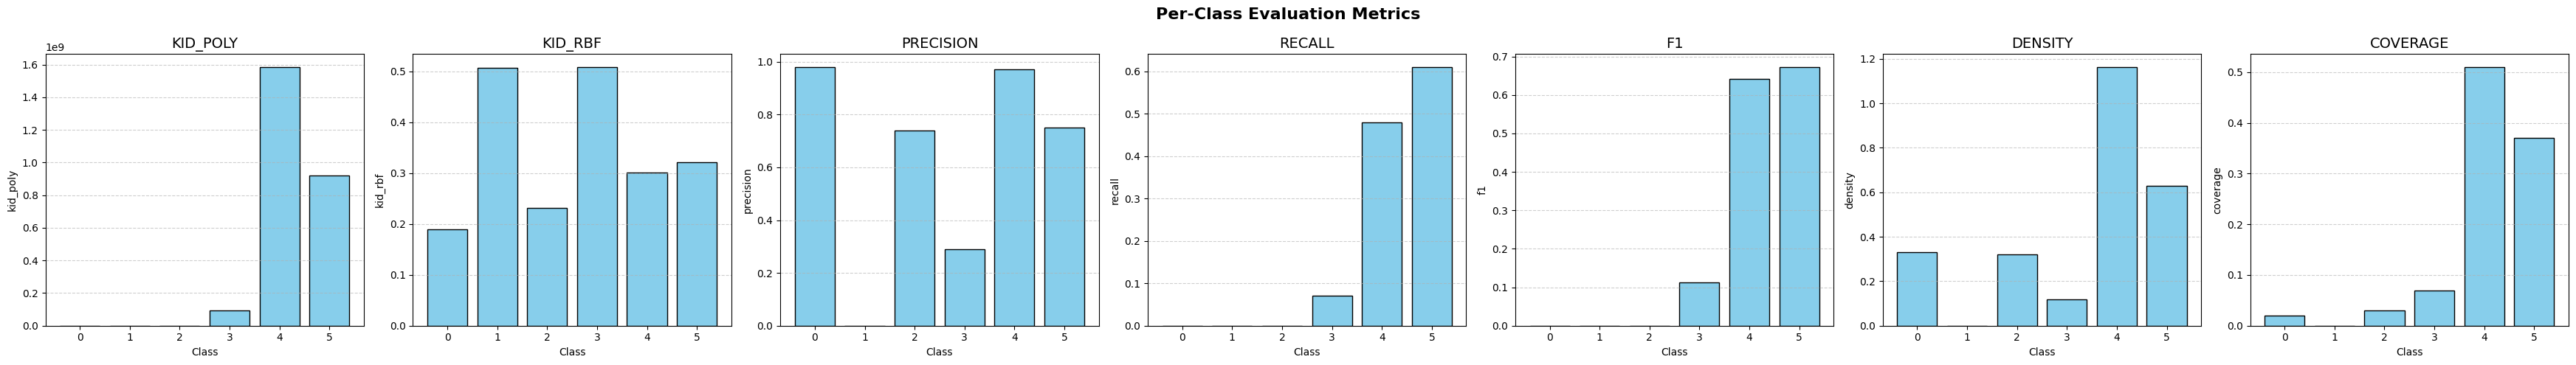

In [16]:
# real_list_flow, real_list_flow_t = compute_features(
#     real_list_flow, real_list_flow_t, classifier
# )

# visualize_tsne_per_class(real_list_flow, real_list_flow_t)

# metrics_per_class_flow = evaluate_features(real_list_flow, real_list_flow_t)

# plot_metrics_per_class(metrics_per_class_flow)

x1_features_flow, real_features_flow = compute_features(
    x1_list_flow, real_list_flow, classifier
)

visualize_tsne_per_class(x1_features_flow, real_features_flow)

metrics_per_class_flow = evaluate_features(x1_features_flow, real_features_flow)

plot_metrics_per_class(metrics_per_class_flow)

In [17]:
num_timesteps = 10
samples_per_class = 100
guidance_scale = 2.0

flow_generator = ScoreGenerator(
    path=path,
    backbone=backbone,
    num_timesteps=num_timesteps,
    null_class=sampeable.num_classes,
    device=device,
)

x1_list_score, real_list_score = compute_samples(
    generator=flow_generator,
    p_data=val_sampeable,
    samples_per_class=samples_per_class,
    num_classes=sampeable.num_classes,
    device=device,
    guidance_scale=guidance_scale,
)

# visualize_samples_per_class(x1_list_score, real_list_score)

100%|██████████| 9/9 [00:05<00:00,  1.52it/s]


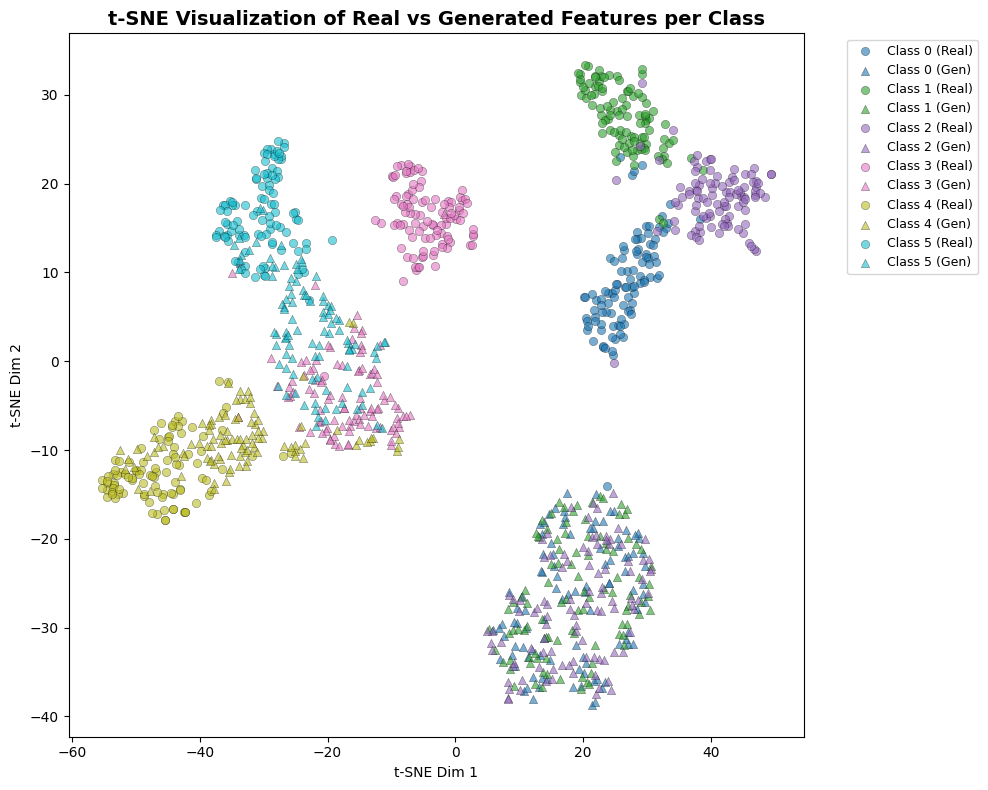

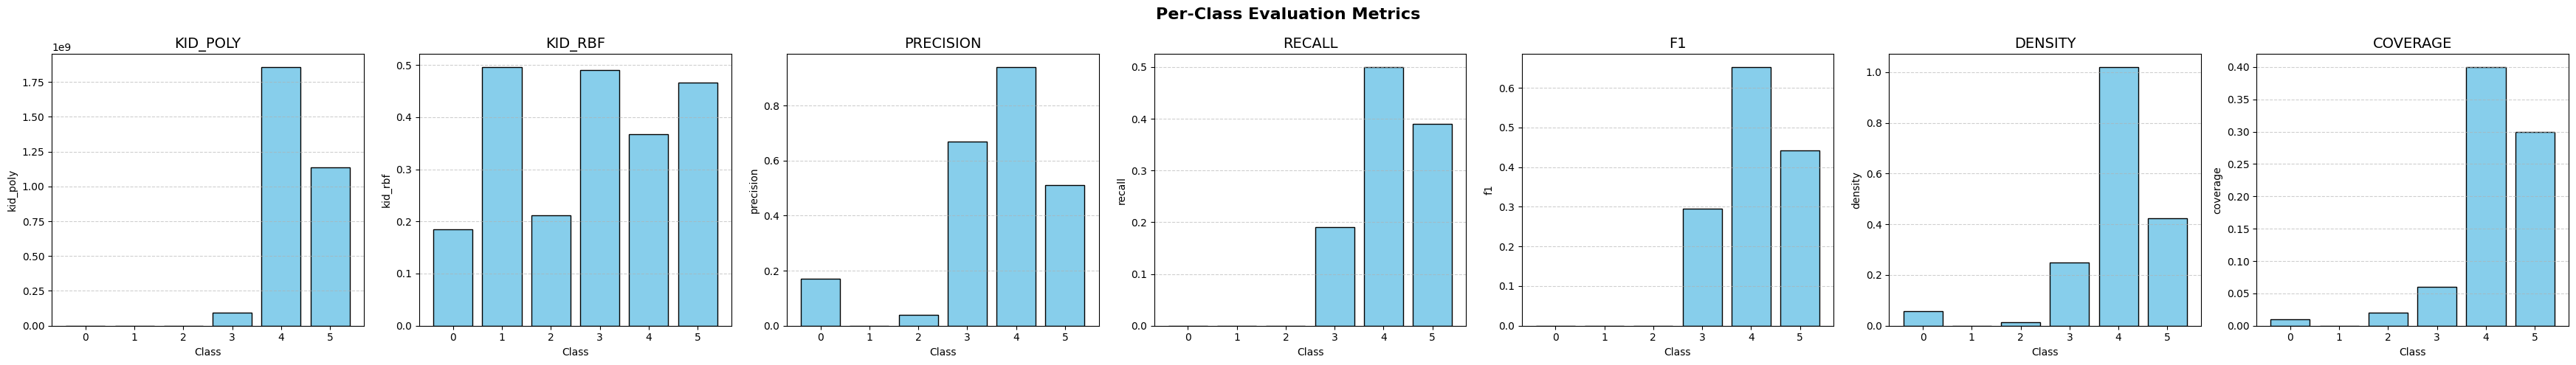

In [18]:
x1_features_score, real_features_score = compute_features(
    x1_list_score, real_list_score, classifier
)

visualize_tsne_per_class(x1_features_score, real_features_score)

metrics_per_class_score = evaluate_features(x1_features_score, real_features_score)

plot_metrics_per_class(metrics_per_class_score)

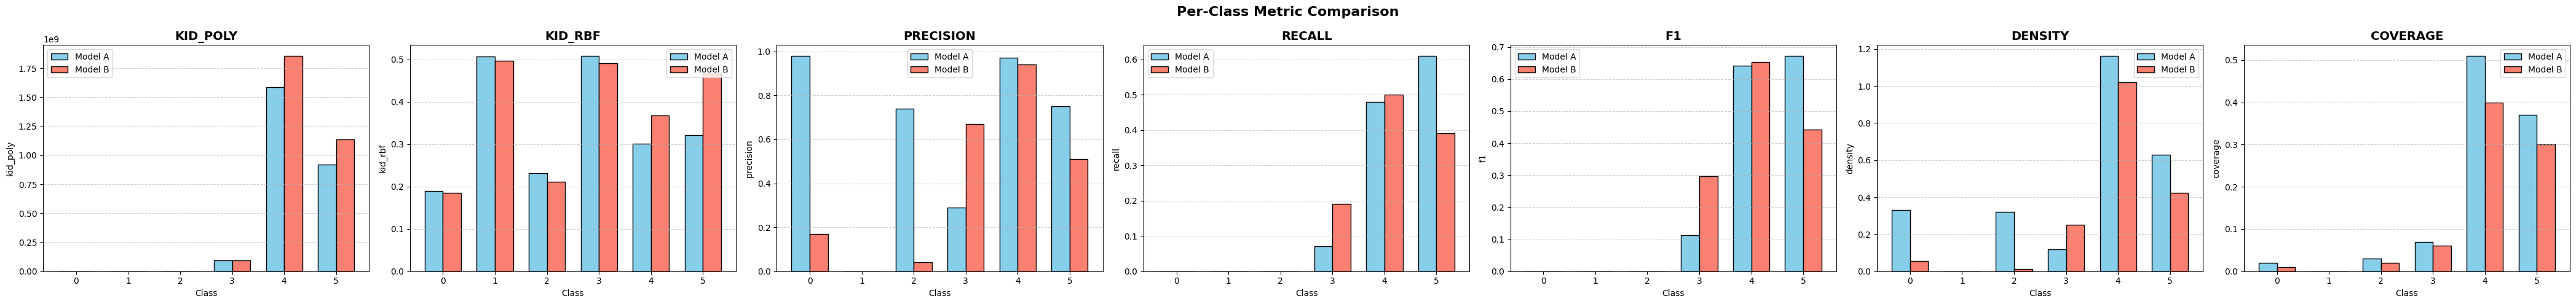

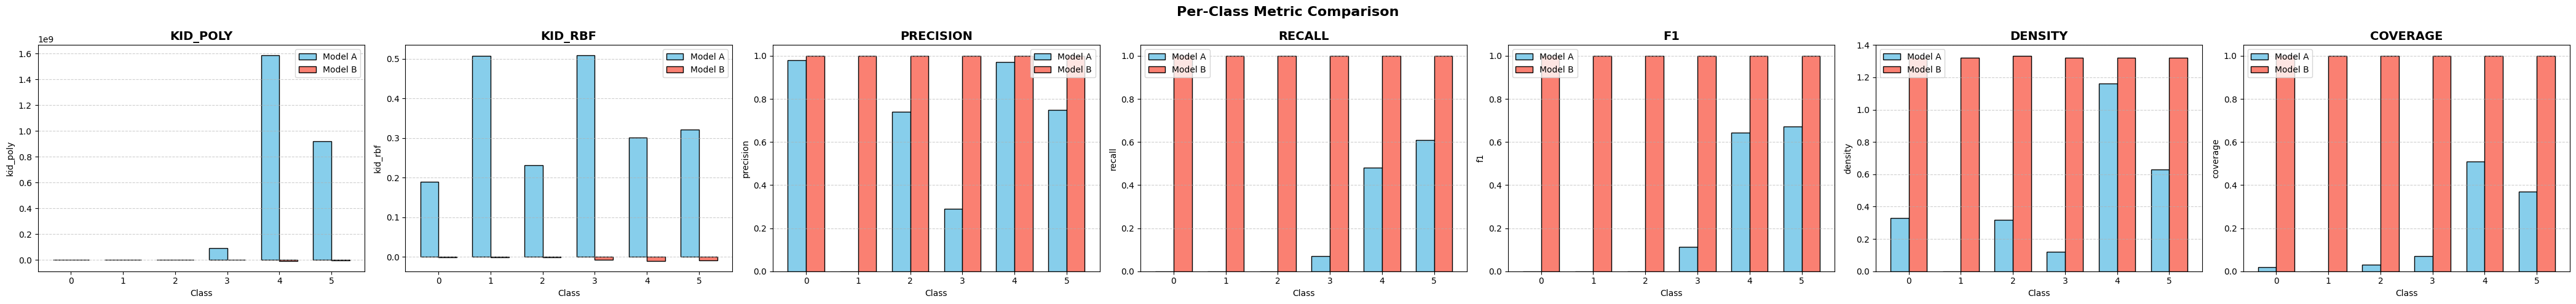

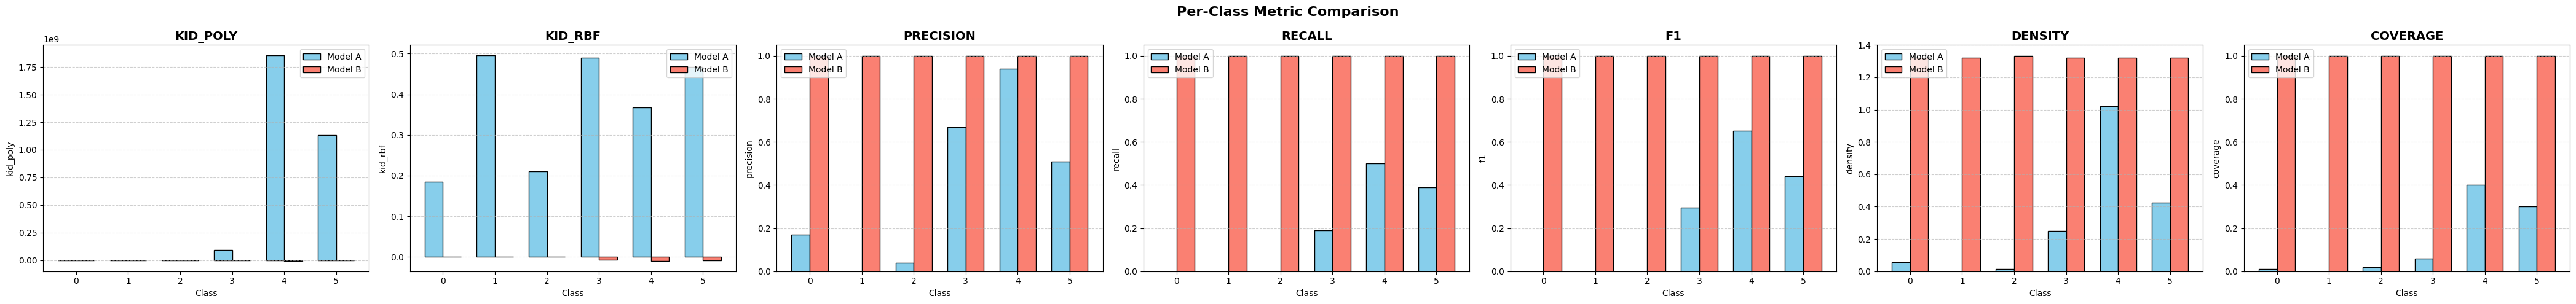

In [19]:
from diffusion.evaluation.evaluate import compare_metrics_per_class

metrics_per_class_perfect = evaluate_features(x1_features_score, x1_features_score)

compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_score)
compare_metrics_per_class(metrics_per_class_flow, metrics_per_class_perfect)
compare_metrics_per_class(metrics_per_class_score, metrics_per_class_perfect)